# OOF Voting and Leakage-Safe Stacking

This notebook takes the best tuned version of each model (XGBoost, LightGBM, CatBoost) and tests three ways of combining them: simple averaging, weighted averaging, and a logistic-regression stacker. The weights and the stacker are learned in a cross-fitted way, only ever using out-of-fold data, so the ensembling step itself does not leak either.


## Import libraries


In [3]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
print("Libraries imported successfully.")


Libraries imported successfully.


## Set paths and experiment settings


In [5]:
current_folder = Path.cwd().resolve()
project_root = current_folder.parent if current_folder.name == "notebooks" else current_folder

xgboost_path = project_root / "data" / "modeling" / "xgboost_tuning_results" / "xgboost_tuning_oof_predictions.pkl"
lightgbm_path = project_root / "data" / "modeling" / "lightgbm_tuning_results" / "lightgbm_tuning_oof_predictions.pkl"
catboost_path = project_root / "data" / "modeling" / "catboost_tuning_results" / "native_catboost_oof_predictions.pkl"
test_ids_path = project_root / "data" / "modeling" / "splits" / "test_ids.csv"

result_folder = project_root / "data" / "modeling" / "ensemble_results"
figure_folder = project_root / "reports" / "figures"
audit_folder = project_root / "reports" / "audits"
for folder in [result_folder, figure_folder, audit_folder]:
    folder.mkdir(parents=True, exist_ok=True)
for path in [xgboost_path, lightgbm_path, catboost_path, test_ids_path]:
    assert path.exists(), f"Required file missing: {path}"

EXPECTED_TRAINING_ROWS = 246008
RANDOM_STATE = 2026
BASE_MODELS = ["xgboost", "lightgbm", "catboost"]
BEST_COLUMNS = {
    "xgboost": "xgb_depth5_regularized",
    "lightgbm": "lgb_leaves48_regularized",
    "catboost": "native_depth7_regularized",
}
STACKING_C_VALUES = [0.01, 0.1, 1.0, 10.0]
WEIGHT_STEP = 0.05
print("Base models:", BASE_MODELS)
print("Weight search step:", WEIGHT_STEP)


Base models: ['xgboost', 'lightgbm', 'catboost']
Weight search step: 0.05


## Load and align the best OOF predictions


In [7]:
xgb_oof = pd.read_pickle(xgboost_path)
lgb_oof = pd.read_pickle(lightgbm_path)
cat_oof = pd.read_pickle(catboost_path)
test_id_set = set(pd.read_csv(test_ids_path)["SK_ID_CURR"])

oof_data = xgb_oof[
    ["SK_ID_CURR", "TARGET", "FOLD", BEST_COLUMNS["xgboost"]]
].rename(columns={BEST_COLUMNS["xgboost"]: "xgboost"})

oof_data = oof_data.merge(
    lgb_oof[["SK_ID_CURR", "TARGET", "FOLD", BEST_COLUMNS["lightgbm"]]].rename(
        columns={"TARGET": "TARGET_lgb", "FOLD": "FOLD_lgb",
                 BEST_COLUMNS["lightgbm"]: "lightgbm"}
    ),
    on="SK_ID_CURR", how="inner", validate="one_to_one"
)
oof_data = oof_data.merge(
    cat_oof[["SK_ID_CURR", "TARGET", "FOLD", BEST_COLUMNS["catboost"]]].rename(
        columns={"TARGET": "TARGET_cat", "FOLD": "FOLD_cat",
                 BEST_COLUMNS["catboost"]: "catboost"}
    ),
    on="SK_ID_CURR", how="inner", validate="one_to_one"
)

assert oof_data["TARGET"].equals(oof_data["TARGET_lgb"])
assert oof_data["TARGET"].equals(oof_data["TARGET_cat"])
assert oof_data["FOLD"].equals(oof_data["FOLD_lgb"])
assert oof_data["FOLD"].equals(oof_data["FOLD_cat"])
oof_data = oof_data.drop(columns=["TARGET_lgb", "FOLD_lgb", "TARGET_cat", "FOLD_cat"])
oof_data = oof_data.sort_values("SK_ID_CURR").reset_index(drop=True)

assert len(oof_data) == EXPECTED_TRAINING_ROWS
assert oof_data["SK_ID_CURR"].is_unique
assert not oof_data["SK_ID_CURR"].isin(test_id_set).any()
assert not oof_data[BASE_MODELS].isna().any().any()
print("Aligned OOF rows:", len(oof_data))
print("Folds:", sorted(oof_data["FOLD"].unique()))
print("Final test evaluations performed: 0")


Aligned OOF rows: 246008
Folds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Final test evaluations performed: 0


Pulls in the best tuned out-of-fold predictions from each of the three previous tuning notebooks and lines them up by applicant, so they can be compared and combined fairly.


## Measure prediction diversity


In [10]:
pearson_correlation = oof_data[BASE_MODELS].corr(method="pearson")
spearman_correlation = oof_data[BASE_MODELS].corr(method="spearman")

# Residuals show whether the models make similar probability errors.
residuals = oof_data[BASE_MODELS].subtract(oof_data["TARGET"], axis=0)
residual_correlation = residuals.corr()

diversity_rows = []
for first_index, first_model in enumerate(BASE_MODELS):
    for second_model in BASE_MODELS[first_index + 1:]:
        absolute_difference = np.abs(oof_data[first_model] - oof_data[second_model])
        diversity_rows.append({
            "model_1": first_model,
            "model_2": second_model,
            "pearson_correlation": pearson_correlation.loc[first_model, second_model],
            "spearman_correlation": spearman_correlation.loc[first_model, second_model],
            "residual_correlation": residual_correlation.loc[first_model, second_model],
            "mean_absolute_probability_difference": absolute_difference.mean(),
            "percent_difference_over_0_02": (absolute_difference > 0.02).mean() * 100,
        })
diversity_table = pd.DataFrame(diversity_rows)
display(diversity_table.round(5))
display(pearson_correlation.round(5))


,model_1,model_2,pearson_correlation,spearman_correlation,residual_correlation,mean_absolute_probability_difference,percent_difference_over_0_02
0,xgboost,lightgbm,0.98229,0.9836,0.99763,0.01015,14.18816
1,xgboost,catboost,0.96502,0.9660,0.99536,0.01425,20.99688
2,lightgbm,catboost,0.96423,0.9667,0.99539,0.01416,20.86355


,xgboost,lightgbm,catboost
xgboost,1.00000,0.98229,0.96502
lightgbm,0.98229,1.00000,0.96423
catboost,0.96502,0.96423,1.00000


The three models agree with each other about 96-98% of the time (correlation-wise), which isn't surprising since they're all boosted trees trained on the same data. This still leaves a little room for combining them to help, just not a huge amount.


## Metric and ensemble helper functions


In [13]:
def calculate_metrics(y_true, probability):
    probability = np.asarray(probability)

    return {
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
    }

def probability_to_logit(probability):
    probability = np.clip(np.asarray(probability), 1e-6, 1 - 1e-6)
    return np.log(probability / (1 - probability))

def make_stacker(c_value):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=c_value, penalty="l2", solver="lbfgs",
            max_iter=2000, random_state=RANDOM_STATE
        )),
    ])

weight_values = np.round(np.arange(0, 1 + WEIGHT_STEP / 2, WEIGHT_STEP), 10)
weight_candidates = []
for xgb_weight in weight_values:
    for lgb_weight in weight_values:
        cat_weight = round(1.0 - xgb_weight - lgb_weight, 10)
        if cat_weight >= 0:
            weight_candidates.append((xgb_weight, lgb_weight, cat_weight))
print("Constrained voting combinations:", len(weight_candidates))


Constrained voting combinations: 231


Sets up the scoring function and the ensemble-building pieces, weighted voting and logistic-regression stacking.


## Cross-fit weighted voting and stacking


In [16]:
meta_predictions = oof_data[
    ["SK_ID_CURR", "TARGET", "FOLD"] + BASE_MODELS
].copy()
meta_predictions["equal_vote"] = meta_predictions[BASE_MODELS].mean(axis=1)
meta_predictions["weighted_vote"] = np.nan
meta_predictions["logistic_stack"] = np.nan

weight_rows = []
stacking_rows = []

for outer_fold in sorted(oof_data["FOLD"].unique()):
    meta_train_mask = oof_data["FOLD"].ne(outer_fold)
    meta_valid_mask = oof_data["FOLD"].eq(outer_fold)
    train_probabilities = oof_data.loc[meta_train_mask, BASE_MODELS].to_numpy()
    train_target = oof_data.loc[meta_train_mask, "TARGET"].to_numpy()
    valid_probabilities = oof_data.loc[meta_valid_mask, BASE_MODELS].to_numpy()

    # Select voting weights using only the meta-training rows.
    weight_scores = []
    for weights in weight_candidates:
        train_blend = train_probabilities @ np.asarray(weights)
        weight_scores.append((
            roc_auc_score(train_target, train_blend),
            average_precision_score(train_target, train_blend),
            weights
        ))
    _, _, selected_weights = max(weight_scores, key=lambda row: (row[0], row[1]))
    meta_predictions.loc[meta_valid_mask, "weighted_vote"] = (
        valid_probabilities @ np.asarray(selected_weights)
    )
    weight_rows.append({
        "outer_fold": int(outer_fold),
        "xgboost_weight": selected_weights[0],
        "lightgbm_weight": selected_weights[1],
        "catboost_weight": selected_weights[2],
    })

    # Tune stacking C using only folds contained in the meta-training data.
    inner_scores = []
    inner_fold_values = sorted(oof_data.loc[meta_train_mask, "FOLD"].unique())
    for c_value in STACKING_C_VALUES:
        inner_prediction = np.full(meta_train_mask.sum(), np.nan)
        meta_train_frame = oof_data.loc[meta_train_mask].reset_index(drop=True)
        for inner_fold in inner_fold_values:
            inner_train = meta_train_frame["FOLD"].ne(inner_fold)
            inner_valid = meta_train_frame["FOLD"].eq(inner_fold)
            inner_model = make_stacker(c_value)
            inner_model.fit(
                probability_to_logit(meta_train_frame.loc[inner_train, BASE_MODELS]),
                meta_train_frame.loc[inner_train, "TARGET"]
            )
            inner_prediction[inner_valid.to_numpy()] = inner_model.predict_proba(
                probability_to_logit(meta_train_frame.loc[inner_valid, BASE_MODELS])
            )[:, 1]
        assert not np.isnan(inner_prediction).any()
        inner_scores.append((
            roc_auc_score(meta_train_frame["TARGET"], inner_prediction),
            average_precision_score(meta_train_frame["TARGET"], inner_prediction),
            c_value
        ))

    _, _, selected_c = max(inner_scores, key=lambda row: (row[0], row[1]))
    final_stacker = make_stacker(selected_c)
    final_stacker.fit(
        probability_to_logit(oof_data.loc[meta_train_mask, BASE_MODELS]),
        oof_data.loc[meta_train_mask, "TARGET"]
    )
    meta_predictions.loc[meta_valid_mask, "logistic_stack"] = final_stacker.predict_proba(
        probability_to_logit(oof_data.loc[meta_valid_mask, BASE_MODELS])
    )[:, 1]
    stacking_rows.append({"outer_fold": int(outer_fold), "selected_C": selected_c})

    print(
        f"Fold {outer_fold}: weights={selected_weights}, "
        f"stacking C={selected_c}"
    )

weight_table = pd.DataFrame(weight_rows)
stacking_parameter_table = pd.DataFrame(stacking_rows)
assert not meta_predictions[["weighted_vote", "logistic_stack"]].isna().any().any()
print("Cross-fitted ensemble predictions completed.")


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear

Fold 1: weights=(np.float64(0.35), np.float64(0.3), np.float64(0.35)), stacking C=0.01


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear

Fold 2: weights=(np.float64(0.25), np.float64(0.35), np.float64(0.4)), stacking C=0.01


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear

...

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear

Fold 4: weights=(np.float64(0.3), np.float64(0.3), np.float64(0.4)), stacking C=0.01


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear

Fold 5: weights=(np.float64(0.3), np.float64(0.35), np.float64(0.35)), stacking C=0.01
Cross-fitted ensemble predictions completed.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


For each outer fold, the voting weights and the stacking model are chosen using only the other four folds' data, then applied to the held-out fold. This keeps the ensembling step itself leakage-free, the same principle used for tuning earlier.


## Compare individual models and ensembles


In [19]:
evaluated_models = BASE_MODELS + ["equal_vote", "weighted_vote", "logistic_stack"]
overall_rows = []
fold_rows = []

for model_name in evaluated_models:
    metrics = calculate_metrics(meta_predictions["TARGET"], meta_predictions[model_name])
    metrics["model"] = model_name
    overall_rows.append(metrics)
    for fold_number in sorted(meta_predictions["FOLD"].unique()):
        fold_mask = meta_predictions["FOLD"].eq(fold_number)
        fold_metrics = calculate_metrics(
            meta_predictions.loc[fold_mask, "TARGET"],
            meta_predictions.loc[fold_mask, model_name]
        )
        fold_metrics.update({"model": model_name, "fold": int(fold_number)})
        fold_rows.append(fold_metrics)

overall_metrics = pd.DataFrame(overall_rows).sort_values(
    ["roc_auc", "pr_auc"], ascending=False
).reset_index(drop=True)
fold_metrics = pd.DataFrame(fold_rows)
best_individual_auc = overall_metrics.loc[
    overall_metrics["model"].isin(BASE_MODELS), "roc_auc"
].max()
overall_metrics["auc_gain_over_best_individual"] = (
    overall_metrics["roc_auc"] - best_individual_auc
)
overall_metrics.round(6)


,roc_auc,pr_auc,model,auc_gain_over_best_individual
0,0.791449,0.285701,equal_vote,0.001789
1,0.791396,0.285695,weighted_vote,0.001735
2,0.791357,0.285652,logistic_stack,0.001696
3,0.789661,0.282529,lightgbm,0.000000
4,0.789620,0.282323,xgboost,-0.000040
5,0.788938,0.282501,catboost,-0.000722


Equal voting comes out ahead of both weighted voting and stacking, though all three ensembles beat every individual model. The gain over the best individual model is small (+0.0018), which makes sense since the three models are already highly correlated with each other.


## Review learned ensemble parameters


In [22]:
display(weight_table)
display(weight_table[["xgboost_weight", "lightgbm_weight", "catboost_weight"]].agg(["mean", "std"]).round(4))
display(stacking_parameter_table)

print("Best overall method:", overall_metrics.iloc[0]["model"])
print("Best OOF ROC AUC:", round(overall_metrics.iloc[0]["roc_auc"], 6))
print(
    "Gain over best individual:",
    round(overall_metrics.iloc[0]["auc_gain_over_best_individual"], 6)
)


,outer_fold,xgboost_weight,lightgbm_weight,catboost_weight
0,1,0.35,0.30,0.35
1,2,0.25,0.35,0.40
2,3,0.40,0.25,0.35
3,4,0.30,0.30,0.40
4,5,0.30,0.35,0.35


,xgboost_weight,lightgbm_weight,catboost_weight
mean,0.320,0.3100,0.3700
std,0.057,0.0418,0.0274


,outer_fold,selected_C
0,1,0.01
1,2,0.01
2,3,0.01
3,4,0.01
4,5,0.01


Best overall method: equal_vote
Best OOF ROC AUC: 0.791449
Gain over best individual: 0.001789


The voting weights land close to equal across folds (roughly a third each, with CatBoost getting a bit more), and the stacker consistently picks a small C value, meaning it leans toward simple averaging rather than trusting one model much more than the others. This is part of why equal voting ends up winning, there isn't much room for a smarter combination to improve on a plain average.


## Plot OOF curves


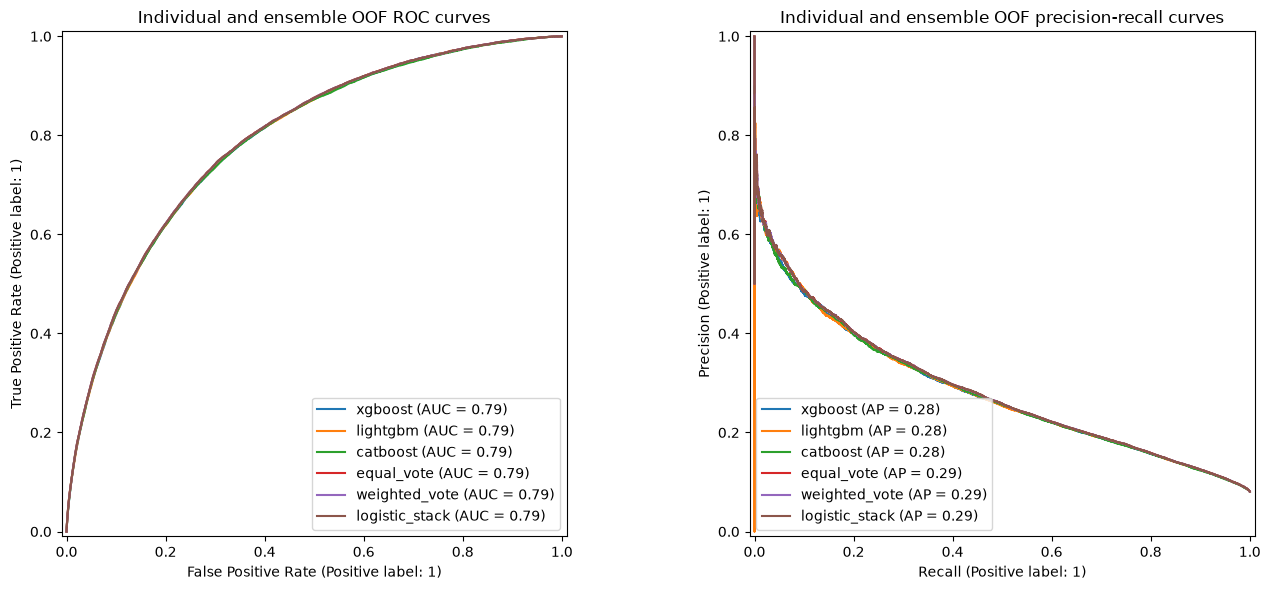

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for model_name in evaluated_models:
    RocCurveDisplay.from_predictions(
        meta_predictions["TARGET"], meta_predictions[model_name],
        name=model_name, ax=axes[0]
    )
    PrecisionRecallDisplay.from_predictions(
        meta_predictions["TARGET"], meta_predictions[model_name],
        name=model_name, ax=axes[1]
    )
axes[0].set_title("Individual and ensemble OOF ROC curves")
axes[1].set_title("Individual and ensemble OOF precision-recall curves")
plt.tight_layout()
plt.savefig(figure_folder / "oof_voting_and_stacking_curves.png", dpi=160, bbox_inches="tight")
plt.show()


Shows all three individual models and all three ensemble methods together, the ensemble curves sit slightly above the individual ones.


## Validate and save outputs


In [28]:
validation_checks = pd.DataFrame([
    {"check": "Complete training dataset used", "passed": len(oof_data) == EXPECTED_TRAINING_ROWS},
    {"check": "All five predefined folds used", "passed": oof_data["FOLD"].nunique() == 5},
    {"check": "Applicant IDs unique and aligned", "passed": oof_data["SK_ID_CURR"].is_unique},
    {"check": "Base OOF predictions complete", "passed": not oof_data[BASE_MODELS].isna().any().any()},
    {"check": "Ensemble OOF predictions complete", "passed": not meta_predictions[evaluated_models].isna().any().any()},
    {"check": "Final test excluded", "passed": not oof_data["SK_ID_CURR"].isin(test_id_set).any()},
    {"check": "One set of weights selected per fold", "passed": len(weight_table) == 5 and weight_table["outer_fold"].nunique() == 5},
    {"check": "Voting weights sum to one", "passed": np.allclose(weight_table[["xgboost_weight", "lightgbm_weight", "catboost_weight"]].sum(axis=1), 1.0)},
    {"check": "One stacker setting selected per fold", "passed": len(stacking_parameter_table) == 5 and stacking_parameter_table["outer_fold"].nunique() == 5},
    {"check": "All metrics finite", "passed": np.isfinite(overall_metrics.select_dtypes(include="number").to_numpy()).all()},
])

display(validation_checks)
assert validation_checks["passed"].all(), "At least one ensemble validation check failed."

meta_predictions.to_pickle(result_folder / "ensemble_oof_predictions.pkl")
meta_predictions.to_csv(result_folder / "ensemble_oof_predictions.csv", index=False)
overall_metrics.to_csv(result_folder / "ensemble_overall_metrics.csv", index=False)
fold_metrics.to_csv(result_folder / "ensemble_fold_metrics.csv", index=False)
weight_table.to_csv(result_folder / "cross_fitted_voting_weights.csv", index=False)
stacking_parameter_table.to_csv(result_folder / "cross_fitted_stacking_parameters.csv", index=False)
diversity_table.to_csv(result_folder / "base_model_diversity.csv", index=False)
pearson_correlation.to_csv(result_folder / "base_prediction_correlations.csv")
validation_checks.to_csv(audit_folder / "ensemble_experiment_validation.csv", index=False)

ensemble_summary = {
    "best_method": overall_metrics.iloc[0]["model"],
    "best_oof_roc_auc": float(overall_metrics.iloc[0]["roc_auc"]),
    "best_oof_pr_auc": float(overall_metrics.iloc[0]["pr_auc"]),
    "mean_cross_fitted_weights": weight_table[
        ["xgboost_weight", "lightgbm_weight", "catboost_weight"]
    ].mean().to_dict(),
}
with open(result_folder / "ensemble_summary.json", "w") as file:
    json.dump(ensemble_summary, file, indent=2)

print("Results saved in:", result_folder)
print("Final test evaluations performed: 0")


,check,passed
0,Complete training dataset used,True
1,All five predefined folds used,True
2,Applicant IDs unique and aligned,True
3,Base OOF predictions complete,True
4,Ensemble OOF predictions complete,True
5,Final test excluded,True
6,One set of weights selected per fold,True
7,Voting weights sum to one,True
8,One stacker setting selected per fold,True
9,All metrics finite,True


Results saved in: /Users/taranveersingh/A-MRP/data/modeling/ensemble_results
Final test evaluations performed: 0


All checks passed.


## Main results

Equal voting (a simple average of the three models) came out on top, ROC-AUC 0.791449, a small but real improvement over the best individual model (LightGBM at 0.789661). Weighted voting and stacking landed just behind it, close enough that the extra complexity is not worth it: equal voting is picked as the final ensemble method because it is the simplest and it wins.
